# Branch Tracking and Multiphoton Resonances


This notebook focuses on interpretation rather than sweeping. We drive the qubit at roughly half its bare transition frequency, solve a single Floquet problem, and then ask which bare energy gaps are close to integer multiples of the drive frequency.

That is the cleanest way to explain multiphoton resonances in this API: compare bare transition gaps against $n\Omega$ and let the Floquet helper report which crossings are near resonance.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import FloquetConfig, FloquetProblem, build_target_drive_term, identify_multiphoton_resonances, solve_floquet
from cqed_sim.core import DispersiveTransmonCavityModel, FrameSpec
from tutorials.tutorial_support import GHz, MHz


## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-2.5),
    kerr=0.0,
    n_cav=2,
    n_tr=4,
)
frame = FrameSpec()
drive_frequency = 0.5 * model.transmon_transition_frequency(
    cavity_level=0,
    lower_level=0,
    upper_level=1,
    frame=frame,
)


## Pulse / sequence construction


In [3]:
drive = build_target_drive_term(
    model,
    "qubit",
    amplitude=MHz(12.0),
    frequency=drive_frequency,
    waveform="cos",
    label="half_frequency_qubit_drive",
)
problem = FloquetProblem(
    model=model,
    frame=frame,
    periodic_terms=(drive,),
    period=2.0 * np.pi / drive_frequency,
    label="half_frequency_multiphoton_test",
)

print("Drive frequency / 2pi [GHz]:", drive_frequency / (2.0 * np.pi * 1.0e9))


Drive frequency / 2pi [GHz]: 2.9999999999999996


## Simulation


In [4]:
result = solve_floquet(problem, FloquetConfig(n_time_samples=96))
resonances = identify_multiphoton_resonances(result, max_photon_order=3)

quasienergies_mhz = result.quasienergies / (2.0 * np.pi * 1.0e6)
bare_energies_ghz = result.bare_hamiltonian_eigenenergies / (2.0 * np.pi * 1.0e9)

transition_labels = []
transition_gaps_ghz = []
for upper in range(1, min(5, bare_energies_ghz.size)):
    transition_labels.append(f"0->{upper}")
    transition_gaps_ghz.append(float(bare_energies_ghz[upper] - bare_energies_ghz[0]))
transition_gaps_ghz = np.asarray(transition_gaps_ghz, dtype=float)

harmonic_orders = np.arange(1, 4, dtype=int)
harmonic_frequencies_ghz = harmonic_orders * drive_frequency / (2.0 * np.pi * 1.0e9)

print("Number of identified resonances:", len(resonances))
for item in resonances[:5]:
    print(
        f"states {item.lower_state}->{item.upper_state}, order {item.photon_order}, detuning / 2pi [MHz] = {item.detuning / (2.0 * np.pi * 1.0e6):+.3f}"
    )


Number of identified resonances: 2
states 0->2, order 2, detuning / 2pi [MHz] = +0.000
states 1->3, order 2, detuning / 2pi [MHz] = -2.500


## Analysis / visualization


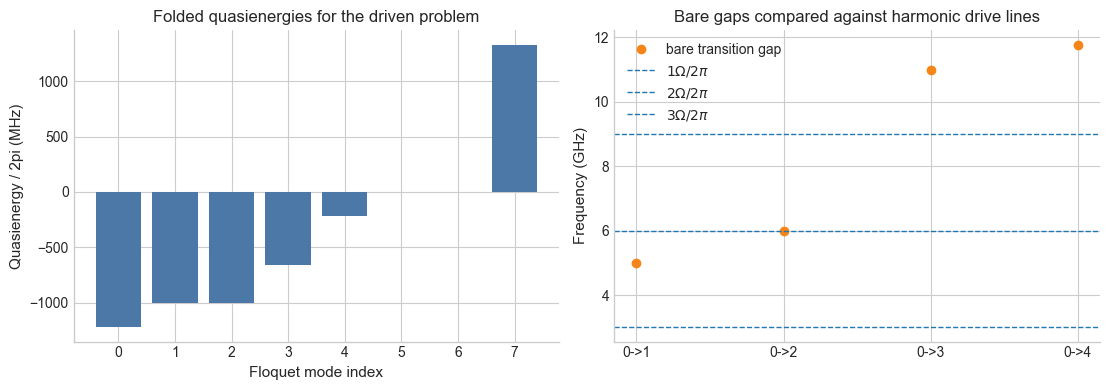

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0))

axes[0].bar(np.arange(quasienergies_mhz.size, dtype=int), quasienergies_mhz, color="#4C78A8")
axes[0].set_xlabel("Floquet mode index")
axes[0].set_ylabel("Quasienergy / 2pi (MHz)")
axes[0].set_title("Folded quasienergies for the driven problem")

axes[1].plot(np.arange(transition_gaps_ghz.size, dtype=int), transition_gaps_ghz, "o", color="#F58518", label="bare transition gap")
for order, frequency_ghz in zip(harmonic_orders, harmonic_frequencies_ghz, strict=True):
    axes[1].axhline(frequency_ghz, lw=1.0, ls="--", label=rf"${order}\Omega / 2\pi$")
axes[1].set_xticks(np.arange(transition_gaps_ghz.size, dtype=int))
axes[1].set_xticklabels(transition_labels)
axes[1].set_ylabel("Frequency (GHz)")
axes[1].set_title("Bare gaps compared against harmonic drive lines")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


## Interpretation


The Floquet solver gives the dressed quasienergies, while `identify_multiphoton_resonances(...)` explains why specific branches interact strongly. In this setup the half-frequency drive makes a second-order resonance especially visible, because a bare transition gap is close to $2\Omega$.

That split view is the right mental model for Floquet work in `cqed_sim`: quasienergies show what the periodic Hamiltonian does, and the resonance helper explains which harmonic condition is responsible.


## Variations / exercises


- Move the drive frequency away from the half-frequency condition and watch the resonance list disappear.
- Increase `max_photon_order` if you want to search for higher-order resonances.
- Return to the sweep notebook and compare the resonance condition with the avoided-crossing locations across detuning.
